## Zadanie 1 - Dekorator mierzący czas wykonania funkcji

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class time_decorator:
    def __init__(self, show_full_stats = False, history_max_len = 1):
        self.history_max_len = history_max_len
        self.show_full_stats = show_full_stats
        self.counter = 0
        self.history = []
         
    def __call__(self, func):
        def wrapper(*args, **kwargs):
            self.counter += 1
            start_time = time.time()
            res = func(*args, **kwargs)
            end_time = time.time()
            
            print(f'Czas wykonania: {(end_time - start_time):.4f}s')

            if len(self.history) >= self.history_max_len:
                self.history.pop(0)
            self.history.append(round((end_time - start_time),4))

            if self.show_full_stats == True:
                print(f'Historia zapisanych czasów: {self.history}')
                print(f'Liczba wykonań funkcji: {self.counter}')
                print(f'Minimalny czas wykonania: {min(self.history):.4f}s')
                print(f'Maksymalny czas wykonania: {max(self.history):.4f}s')
                print(f'Średni czas wykonania: {np.mean(self.history):.4f}s\n')

            return res
        return wrapper

In [3]:
def fibon(n):
    if n<2:
        return n
    return fibon(n-1) + fibon(n-2)

@time_decorator(show_full_stats=True, history_max_len=2)
def fibon2(n):
    return fibon(n)

fibon2(36)
fibon2(36)
fibon2(36)

Czas wykonania: 1.4647s
Historia zapisanych czasów: [1.4647]
Liczba wykonań funkcji: 1
Minimalny czas wykonania: 1.4647s
Maksymalny czas wykonania: 1.4647s
Średni czas wykonania: 1.4647s

Czas wykonania: 1.4149s
Historia zapisanych czasów: [1.4647, 1.4149]
Liczba wykonań funkcji: 2
Minimalny czas wykonania: 1.4149s
Maksymalny czas wykonania: 1.4647s
Średni czas wykonania: 1.4398s

Czas wykonania: 1.4158s
Historia zapisanych czasów: [1.4149, 1.4158]
Liczba wykonań funkcji: 3
Minimalny czas wykonania: 1.4149s
Maksymalny czas wykonania: 1.4158s
Średni czas wykonania: 1.4154s



14930352

In [4]:
@time_decorator(show_full_stats=True, history_max_len=3)
def time_waster(n):
    time.sleep(n)

time_waster(1)
time_waster(1)
time_waster(1)
time_waster(1)
time_waster(1)

Czas wykonania: 1.0006s
Historia zapisanych czasów: [1.0006]
Liczba wykonań funkcji: 1
Minimalny czas wykonania: 1.0006s
Maksymalny czas wykonania: 1.0006s
Średni czas wykonania: 1.0006s

Czas wykonania: 1.0008s
Historia zapisanych czasów: [1.0006, 1.0008]
Liczba wykonań funkcji: 2
Minimalny czas wykonania: 1.0006s
Maksymalny czas wykonania: 1.0008s
Średni czas wykonania: 1.0007s

Czas wykonania: 1.0003s
Historia zapisanych czasów: [1.0006, 1.0008, 1.0003]
Liczba wykonań funkcji: 3
Minimalny czas wykonania: 1.0003s
Maksymalny czas wykonania: 1.0008s
Średni czas wykonania: 1.0006s

Czas wykonania: 1.0005s
Historia zapisanych czasów: [1.0008, 1.0003, 1.0005]
Liczba wykonań funkcji: 4
Minimalny czas wykonania: 1.0003s
Maksymalny czas wykonania: 1.0008s
Średni czas wykonania: 1.0005s

Czas wykonania: 1.0004s
Historia zapisanych czasów: [1.0003, 1.0005, 1.0004]
Liczba wykonań funkcji: 5
Minimalny czas wykonania: 1.0003s
Maksymalny czas wykonania: 1.0005s
Średni czas wykonania: 1.0004s



## Zadanie 2 - klasa `Temperature` i właściwości `@property`

In [5]:
class tempetature:
    def __init__(self, celcius):
        if celcius < -273.15:
            self._celcius = 0
        else:
            self._celcius = celcius

        self._kelvin = self._celcius + 273.15
        self._farenheit = self._celcius * 1.8 + 32

    @property
    def celcius(self):
        return self._celcius
    
    @celcius.setter
    def celcius(self, celcius):
        if celcius < -273.15:
            self._celcius = -273.15
        else:
            self._celcius = celcius

        self._kelvin = self._celcius + 273.15
        self._farenheit = self._celcius * 1.8 + 32
    
    @property
    def kelvin(self):
        return self._kelvin
    
    @kelvin.setter
    def kelvin(self, kelvin):
        if kelvin < 0:
            self._kelvin = 0
        else:
            self._kelvin = kelvin

        self._celcius = self._kelvin - 273.15
        self._farenheit = self._celcius * 1.8 + 32
    
    @property
    def farenheit(self):
        return self._farenheit
    
    @farenheit.setter
    def farenheit(self, farenheit):
        if farenheit < -273.15 * 1.8 + 32:
            self._farenheit = -273.15 * 1.8 + 32
        else:
            self._farenheit = farenheit

        self._celcius = (self._farenheit - 32)/ 1.8
        self._kelvin = self._celcius + 273.15
    
    @property
    def is_freezing(self):
        if self._celcius <= 0:
            return True
        return False
    
    @property
    def is_boiling(self):
        if self._celcius >= 100:
            return True
        return False
    
    @property
    def state(self):
        if self._celcius <= 0:
            return 'solid'
        elif 0 < self._celcius < 100:
            return 'liquid'
        return 'gas'


In [6]:
t = tempetature(25)

print(t.celcius)      # 25
print(t.farenheit)   # 77.0
print(t.kelvin)       # 298.15

t.farenheit = 32
print(t.celcius)      # 0.0
print(t.is_freezing, t.is_boiling)
print(t.state)

t.kelvin = 3000
print(t.celcius)      # 26.85
print(t.is_freezing, t.is_boiling)    
print(t.state)  

t.kelvin = -300      
print(t.kelvin)      # 0
print(t.is_freezing, t.is_boiling)
print(t.state)

25
77.0
298.15
0.0
True False
solid
2726.85
False True
gas
0
True False
solid


## Zadanie 3 - generator liczb pseudolosowych

In [7]:
b = True
1 * (not b)

0

In [8]:
def rng(seed, a, c, m, N, norm = False):
    for _ in range(N):
        seed = (a * seed + c) % m
        yield seed * (not norm) + seed / m * norm

In [9]:
x = rng(1, 5, 3, 16, 100, True)

for i in x:
    print(i)

0.5
0.6875
0.625
0.3125
0.75
0.9375
0.875
0.5625
0.0
0.1875
0.125
0.8125
0.25
0.4375
0.375
0.0625
0.5
0.6875
0.625
0.3125
0.75
0.9375
0.875
0.5625
0.0
0.1875
0.125
0.8125
0.25
0.4375
0.375
0.0625
0.5
0.6875
0.625
0.3125
0.75
0.9375
0.875
0.5625
0.0
0.1875
0.125
0.8125
0.25
0.4375
0.375
0.0625
0.5
0.6875
0.625
0.3125
0.75
0.9375
0.875
0.5625
0.0
0.1875
0.125
0.8125
0.25
0.4375
0.375
0.0625
0.5
0.6875
0.625
0.3125
0.75
0.9375
0.875
0.5625
0.0
0.1875
0.125
0.8125
0.25
0.4375
0.375
0.0625
0.5
0.6875
0.625
0.3125
0.75
0.9375
0.875
0.5625
0.0
0.1875
0.125
0.8125
0.25
0.4375
0.375
0.0625
0.5
0.6875
0.625
0.3125


In [10]:
x = rng(1, 5, 3, 16, 100)

In [11]:
print(next(x))

8.0


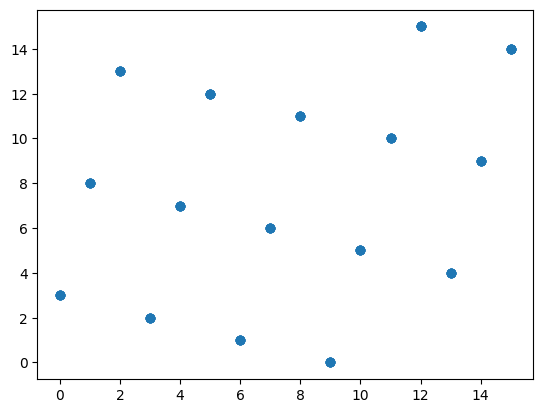

In [12]:
x = rng(10, 5, 3, 16, 100)

numbers = []

for i in x:
    numbers.append(i)

X = numbers[:-1]
Y = numbers[1:]

plt.scatter(X,Y)